In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tqdm import tqdm
from keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
image_data=r"/content/drive/MyDrive/dataset/Faulty_solar_panel"
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,.DS_Store
1,Physical-Damage
2,Electrical-damage
3,Dusty
4,Clean
5,Snow-Covered
6,Bird-drop


In [3]:
train_data_dir =image_data
batch_size = 32
target_size = (224,224)
validation_split = 0.2
train= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="training",
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)
validation= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="validation",
    seed=200,
    image_size=target_size,
    batch_size=batch_size,
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [4]:
class_names = train.class_names
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

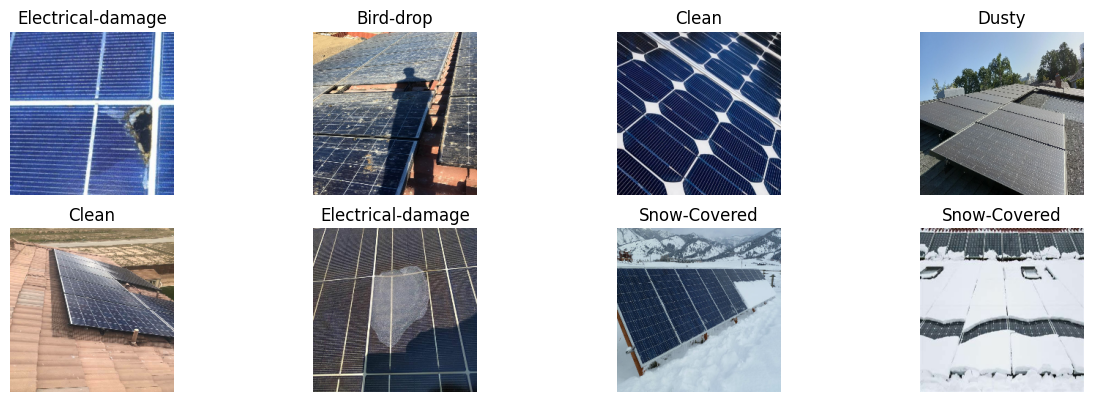

In [5]:
plt.figure(figsize=(15, 20))
for images, labels in train.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
base_model = tf.keras.applications.MobileNetV3Small(input_shape=(224,224,3),include_top=False,weights='imagenet')
base_model.trainable = False
keras_model=keras.models.Sequential()
keras_model.add(base_model)
keras_model.add(keras.layers.Flatten())
keras_model.add(keras.layers.Dropout(0.5))
keras_model.add(keras.layers.Dense(6,activation=tf.nn.softmax))
keras_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       169,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,470 (4.23 MB)

 Trainable params: 169,350 (661.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

keras_model = keras.models.Sequential([
    keras.layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation=tf.nn.softmax)
])
keras_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │       376,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,310 (10.05 MB)

 Trainable params: 376,326 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
keras_model.build()

In [9]:
checkpoint =ModelCheckpoint("kkeras_model.keras", save_best_only=True)

In [10]:
early_stopping =EarlyStopping(patience=5, restore_best_weights=True)

In [11]:
keras_model.compile(optimizer ='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist=keras_model.fit(train,epochs=25,validation_data=validation,callbacks=[checkpoint,early_stopping])

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.5607 - loss: 4.3307 - val_accuracy: 0.8136 - val_loss: 1.4350
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8842 - loss: 0.6917 - val_accuracy: 0.9209 - val_loss: 0.6208
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9619 - loss: 0.2502 - val_accuracy: 0.9322 - val_loss: 0.6124
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9774 - loss: 0.1106 - val_accuracy: 0.9435 - val_loss: 0.4858
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.9816 - loss: 0.1636 - val_accuracy: 0.9435 - val_loss: 0.6460
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9944 - loss: 0.0787 - val_accuracy: 0.9548 - val_loss: 0.5806
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9901 - loss: 0.0630 - val_accuracy: 0.9379 - val_loss: 0.6871
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9873 - loss: 0.1224 - val_accuracy: 0.9435 - val_loss

In [12]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.560734,4.330746,0.813559,1.435027
1,0.884181,0.691668,0.920904,0.620795
2,0.961864,0.250180,0.932203,0.612393
3,0.977401,0.110612,0.943503,0.485828
4,0.981638,0.163557,0.943503,0.645977
5,0.994350,0.078711,0.954802,0.580560
6,0.990113,0.062996,0.937853,0.687112
7,0.987288,0.122417,0.943503,0.703953
8,0.994350,0.105074,0.937853,0.706709


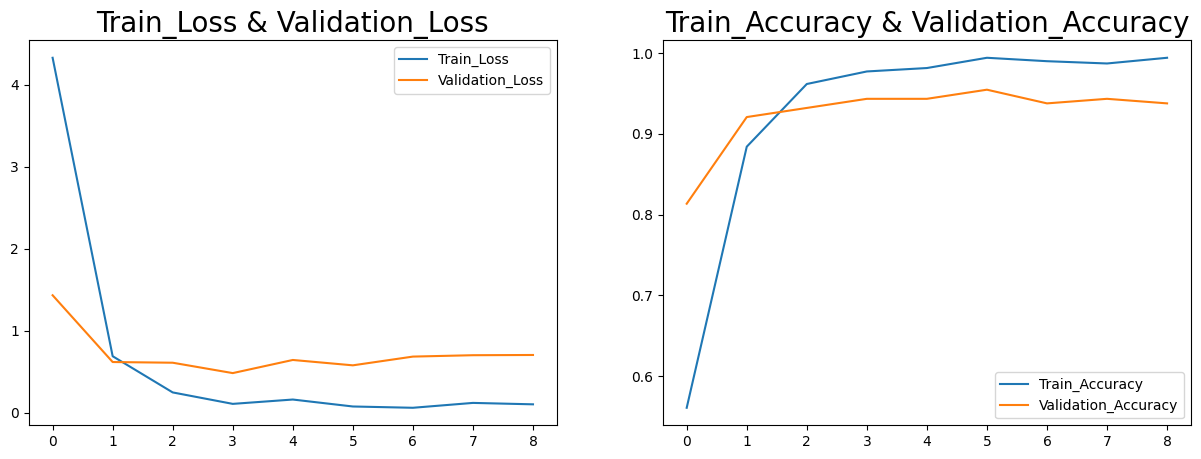

In [13]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

In [14]:
X_val,y_val,y_pred=[],[],[]
for images, labels in validation:
    y_val.extend(labels.numpy())
    X_val.extend(images.numpy())
predictions=keras_model.predict(np.array(X_val))
for i in predictions:
    y_pred.append(np.argmax(i))
df=pd.DataFrame()
df['Actual'],df['Prediction']=y_val,y_pred
df

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


,Actual,Prediction
0,3,3
1,1,1
2,4,4
3,5,5
4,3,3
...,...,...
172,0,0
173,0,0
174,5,5
175,2,2


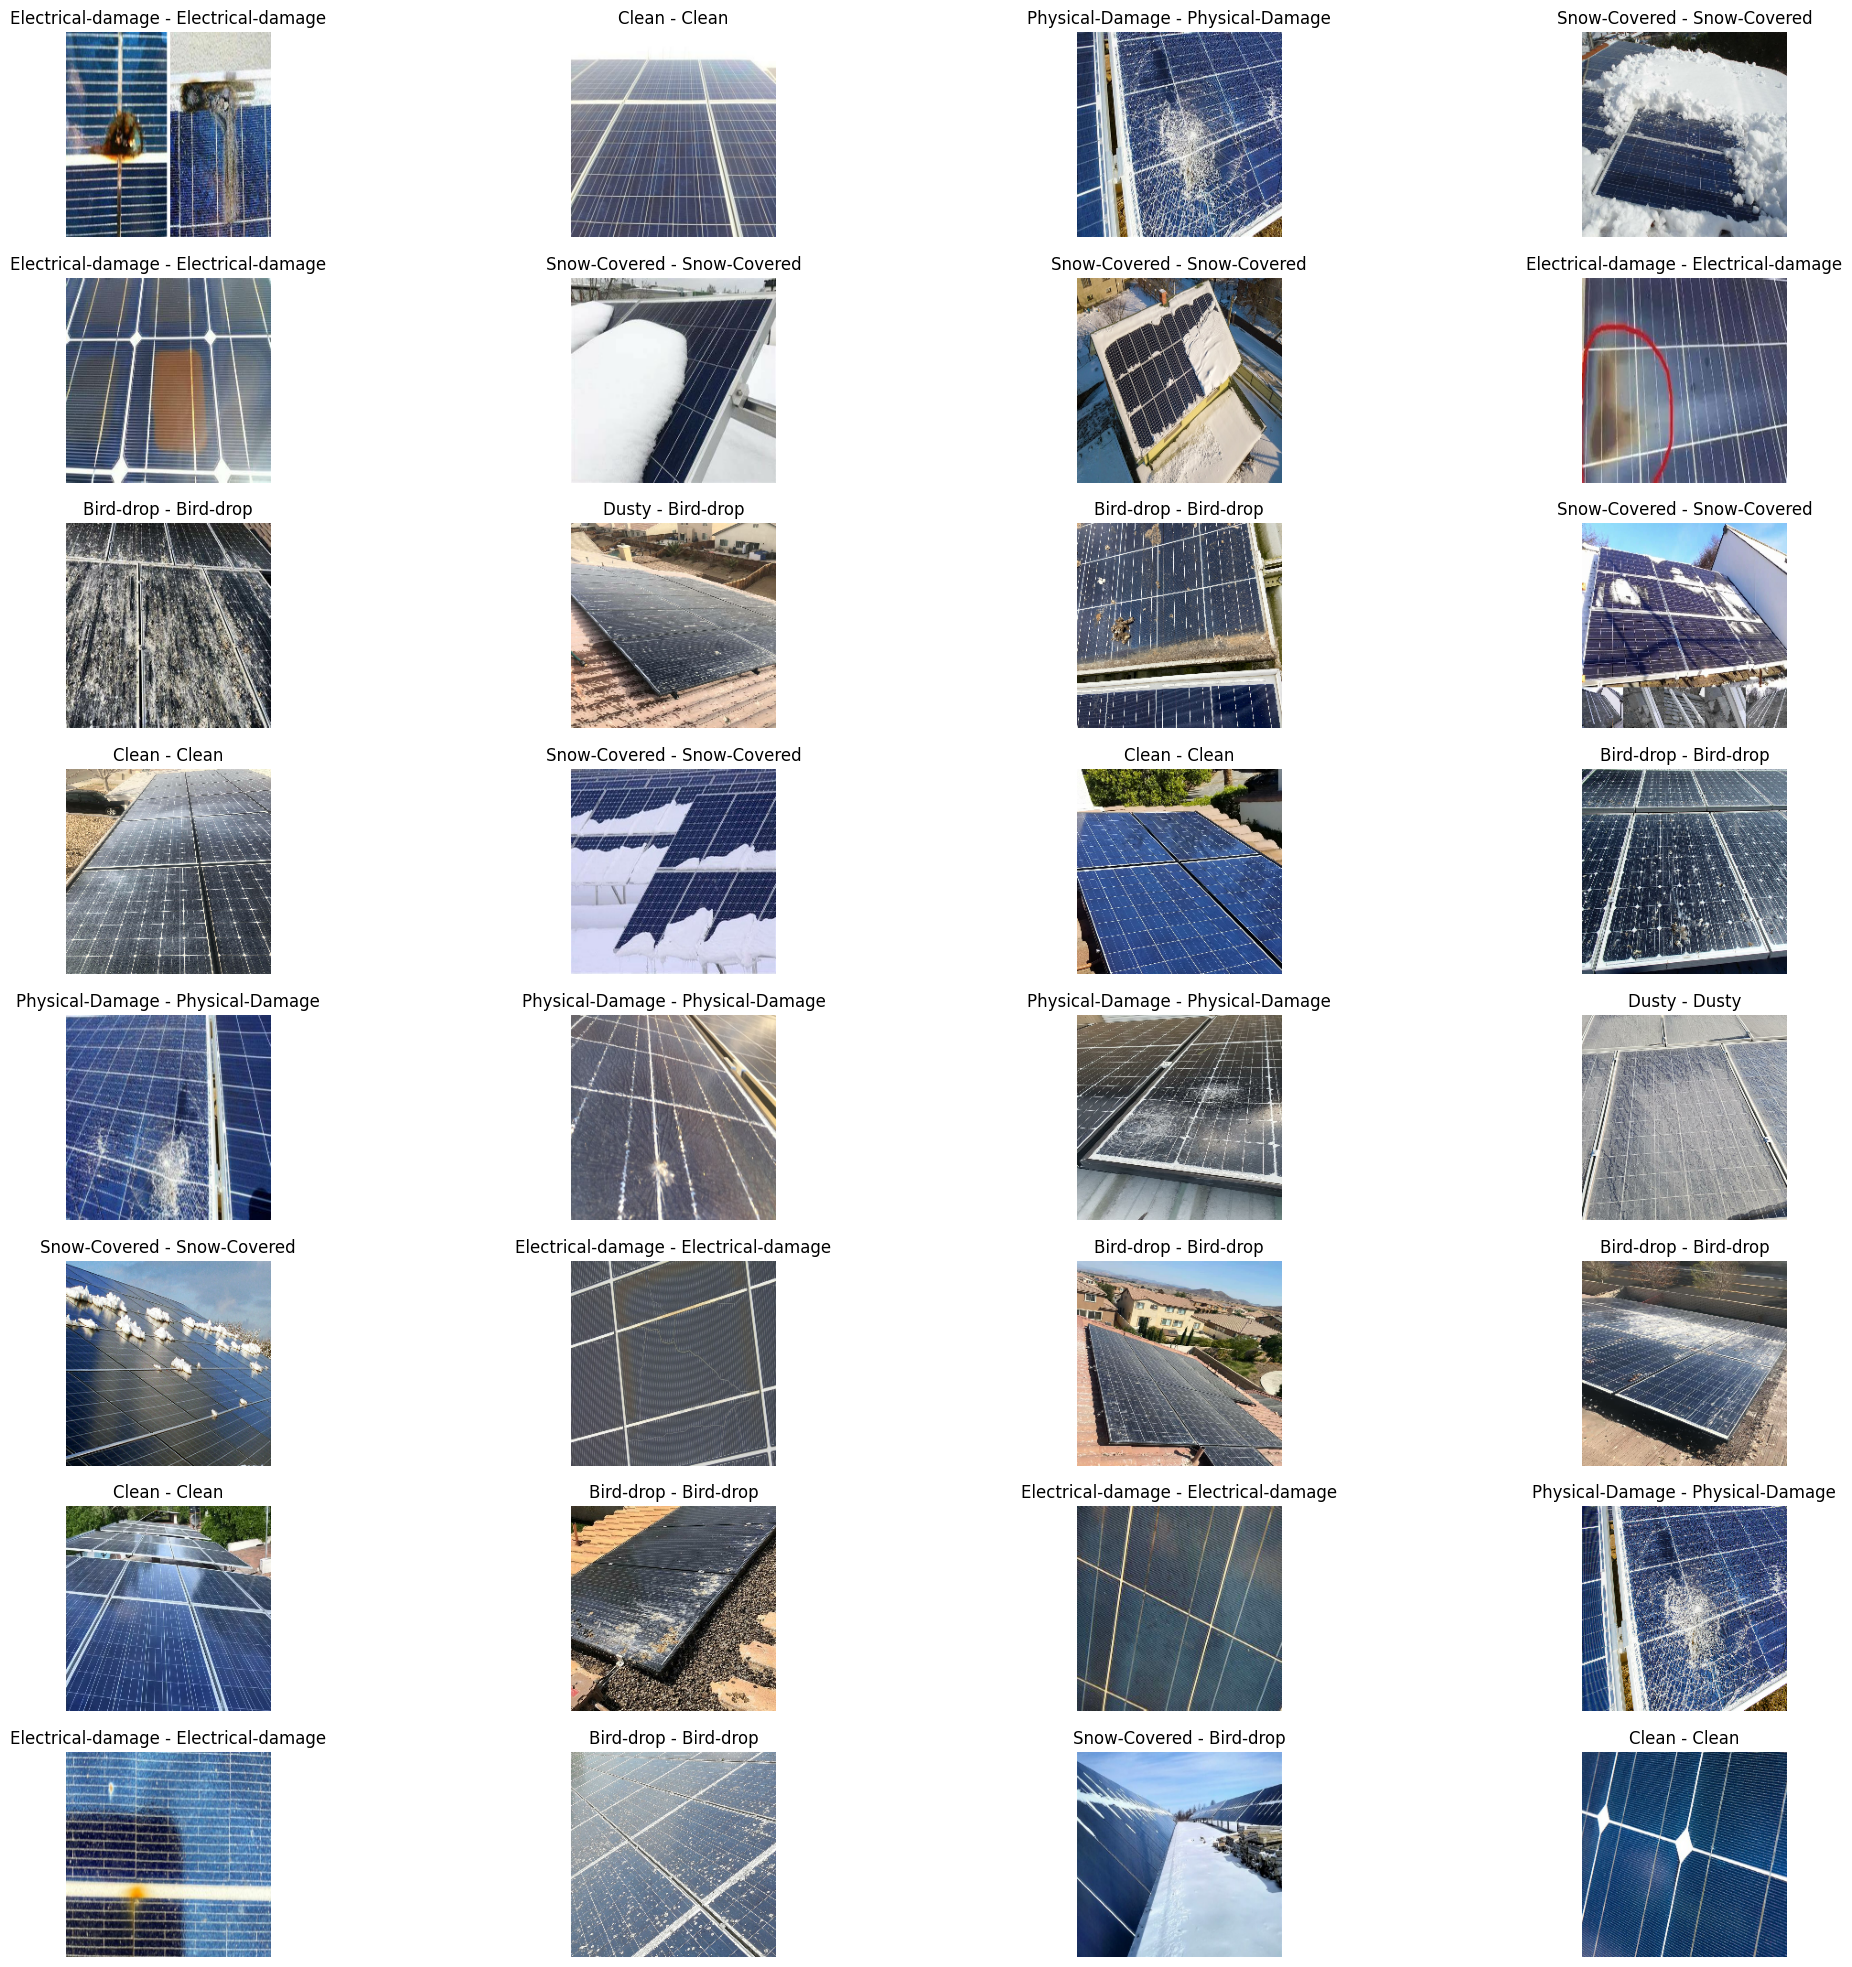

In [15]:
plt.figure(figsize=(25,25))
for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(X_val[i].astype("uint8"))
    plt.title(f'{class_names[y_val[i]]} - {class_names[y_pred[i]]}')
    plt.axis("off")

In [16]:
# ── EfficientNetB0 ──────────────────────────────────────────────
eff_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
eff_base.trainable = False

eff_model = keras.models.Sequential([
    eff_base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
eff_checkpoint = ModelCheckpoint("eff_model.keras", save_best_only=True)
eff_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [18]:
eff_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
eff_hist = eff_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[eff_checkpoint, eff_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.3333 - loss: 1.6320 - val_accuracy: 0.6384 - val_loss: 1.1934
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.5847 - loss: 1.1513 - val_accuracy: 0.7062 - val_loss: 0.9352
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.6695 - loss: 0.9917 - val_accuracy: 0.7345 - val_loss: 0.8069
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.6836 - loss: 0.8970 - val_accuracy: 0.7740 - val_loss: 0.7317
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.7232 - loss: 0.7890 - val_accuracy: 0.7853 - val_loss: 0.6782
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.7726 - loss: 0.7047 - val_accuracy: 0.7797 - val_loss: 0.6314
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.7698 - loss: 0.6636 - val_accuracy: 0.7966 - val_loss: 0.5965
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.7726 - loss: 0.6724 - val_accuracy: 0.8192 - val_loss

In [19]:
eff_hist_ = pd.DataFrame(eff_hist.history)
eff_hist_

,accuracy,loss,val_accuracy,val_loss
0,0.333333,1.631985,0.638418,1.193370
1,0.584746,1.151271,0.706215,0.935171
2,0.669492,0.991721,0.734463,0.806867
3,0.683616,0.897013,0.774011,0.731697
4,0.723164,0.788972,0.785311,0.678173
5,0.772599,0.704681,0.779661,0.631413
6,0.769774,0.663607,0.796610,0.596505
7,0.772599,0.672360,0.819209,0.565683
8,0.807910,0.621407,0.802260,0.542721
9,0.822034,0.582609,0.824859,0.515336


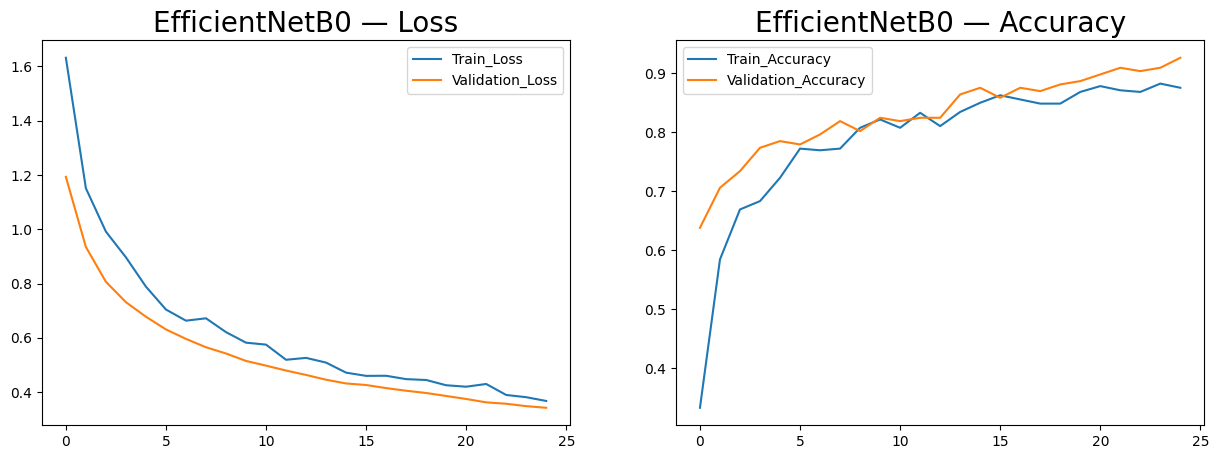

In [20]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(eff_hist_['loss'], label='Train_Loss')
plt.plot(eff_hist_['val_loss'], label='Validation_Loss')
plt.title('EfficientNetB0 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff_hist_['accuracy'], label='Train_Accuracy')
plt.plot(eff_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('EfficientNetB0 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [21]:
eff_y_pred = []
predictions_eff = eff_model.predict(np.array(X_val))  # reuses X_val, y_val from MobileNetV2 section
for i in predictions_eff:
    eff_y_pred.append(np.argmax(i))

print("EfficientNetB0 Accuracy:", accuracy_score(y_val, eff_y_pred))
print(classification_report(y_val, eff_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step
EfficientNetB0 Accuracy: 0.9265536723163842
                   precision    recall  f1-score   support

        Bird-drop       0.90      0.96      0.93        48
            Clean       0.92      0.90      0.91        40
            Dusty       0.92      0.83      0.87        29
Electrical-damage       0.90      0.90      0.90        20
  Physical-Damage       1.00      1.00      1.00        13
     Snow-Covered       0.96      1.00      0.98        27

         accuracy                           0.93       177
        macro avg       0.94      0.93      0.93       177
     weighted avg       0.93      0.93      0.93       177



In [22]:
# ── ShuffleNet (fixed for Keras 3 / TF2) ─────────────────────────
def channel_shuffle(x, groups=2):
    return keras.layers.Lambda(
        lambda t: tf.reshape(
            tf.transpose(
                tf.reshape(t, [-1, tf.shape(t)[1], tf.shape(t)[2], groups, tf.shape(t)[3] // groups]),
                perm=[0, 1, 2, 4, 3]
            ),
            [-1, tf.shape(t)[1], tf.shape(t)[2], tf.shape(t)[3]]
        )
    )(x)

def shuffle_unit(x, out_channels, strides, groups=2):
    in_channels = x.shape[-1]
    bottleneck = out_channels // 4

    if strides == 2:
        shortcut = keras.layers.DepthwiseConv2D(
            kernel_size=3, strides=2, padding='same', use_bias=False)(x)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.Conv2D(
            out_channels // 2, 1, use_bias=False)(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
        shortcut = keras.layers.ReLU()(shortcut)
    else:
        shortcut = x

    residual = keras.layers.Conv2D(bottleneck, 1, use_bias=False)(x)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)
    residual = keras.layers.DepthwiseConv2D(
        kernel_size=3, strides=strides, padding='same', use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.Conv2D(out_channels // 2, 1, use_bias=False)(residual)
    residual = keras.layers.BatchNormalization()(residual)
    residual = keras.layers.ReLU()(residual)

    if strides == 1:
        c = in_channels // 2
        # Use Lambda for slicing instead of direct indexing
        x1 = keras.layers.Lambda(lambda t: t[:, :, :, :c])(x)
        x2 = keras.layers.Lambda(lambda t: t[:, :, :, c:])(x)
        out = keras.layers.Concatenate()([x2, residual])
    else:
        out = keras.layers.Concatenate()([shortcut, residual])

    out = channel_shuffle(out, groups=2)
    return out

def build_shufflenet(input_shape=(224, 224, 3), num_classes=6):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(24, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    stages = [(116, 4), (232, 8), (464, 4)]
    for out_ch, repeats in stages:
        x = shuffle_unit(x, out_ch, strides=2)
        for _ in range(repeats - 1):
            x = shuffle_unit(x, out_ch, strides=1)

    x = keras.layers.Conv2D(1024, 1, use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ShuffleNetV2')

In [23]:
shuffle_model = build_shufflenet(input_shape=(224, 224, 3), num_classes=6)
shuffle_model.summary()

Model: "ShuffleNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        648 │ input_layer_6[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu_14[0][0]    │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │        696 │ max_pooling2d[0]… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        116 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 28, 28,    │        216 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 28, 28,    │        261 │ re_lu_16[0][0]    │
│ (DepthwiseConv2D)   │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        116 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 29)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      1,392 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      1,682 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 1,055,650 (4.03 MB)

 Trainable params: 1,043,646 (3.98 MB)

 Non-trainable params: 12,004 (46.89 KB)

In [24]:
shuffle_checkpoint = ModelCheckpoint("shuffle_model.keras", save_best_only=True)
shuffle_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [25]:
shuffle_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
shuffle_hist = shuffle_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[shuffle_checkpoint, shuffle_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.2938 - loss: 1.7443 - val_accuracy: 0.1638 - val_loss: 1.8230
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.4520 - loss: 1.4519 - val_accuracy: 0.1638 - val_loss: 1.8872
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.4972 - loss: 1.3246 - val_accuracy: 0.1638 - val_loss: 2.0360
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.5537 - loss: 1.1810 - val_accuracy: 0.1638 - val_loss: 2.2371
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5904 - loss: 1.0901 - val_accuracy: 0.1638 - val_loss: 2.5870
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6568 - loss: 0.9578 - val_accuracy: 0.1638 - val_loss: 2.9090


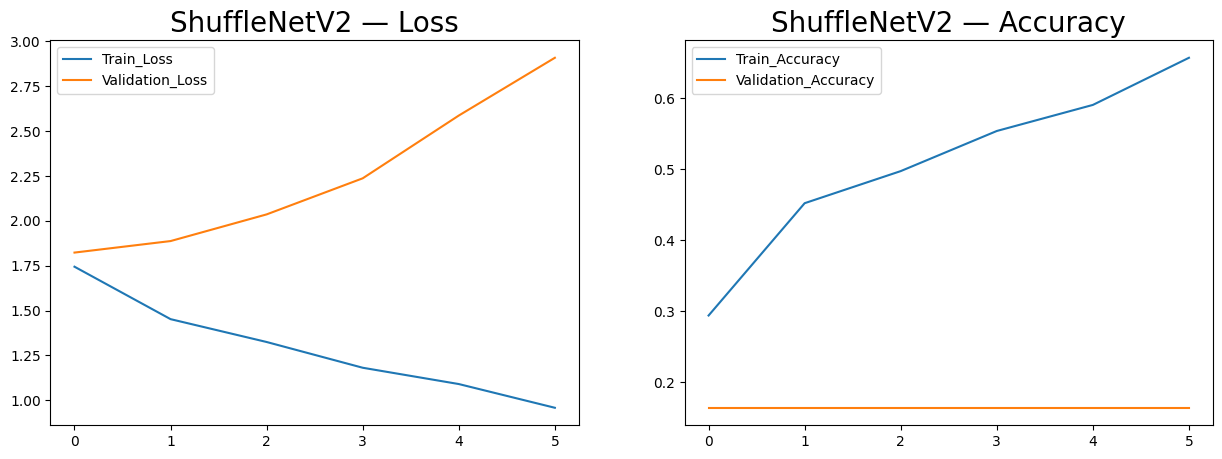

In [26]:
shuffle_hist_ = pd.DataFrame(shuffle_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(shuffle_hist_['loss'], label='Train_Loss')
plt.plot(shuffle_hist_['val_loss'], label='Validation_Loss')
plt.title('ShuffleNetV2 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(shuffle_hist_['accuracy'], label='Train_Accuracy')
plt.plot(shuffle_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('ShuffleNetV2 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [27]:
shuffle_y_pred = []
predictions_shuffle = shuffle_model.predict(np.array(X_val))
for i in predictions_shuffle:
    shuffle_y_pred.append(np.argmax(i))

print("ShuffleNetV2 Accuracy:", accuracy_score(y_val, shuffle_y_pred))
print(classification_report(y_val, shuffle_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 822ms/step
ShuffleNetV2 Accuracy: 0.1638418079096045
                   precision    recall  f1-score   support

        Bird-drop       0.00      0.00      0.00        48
            Clean       0.00      0.00      0.00        40
            Dusty       0.16      1.00      0.28        29
Electrical-damage       0.00      0.00      0.00        20
  Physical-Damage       0.00      0.00      0.00        13
     Snow-Covered       0.00      0.00      0.00        27

         accuracy                           0.16       177
        macro avg       0.03      0.17      0.05       177
     weighted avg       0.03      0.16      0.05       177



In [28]:
# ── VGG16 ────────────────────────────────────────────────────────
vgg_base = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
vgg_base.trainable = False

vgg_model = keras.models.Sequential([
    vgg_base,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
vgg_checkpoint = ModelCheckpoint("vgg_model.keras", save_best_only=True)
vgg_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [30]:
vgg_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
vgg_hist = vgg_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[vgg_checkpoint, vgg_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 592s 26s/step - accuracy: 0.4492 - loss: 24.1079 - val_accuracy: 0.7401 - val_loss: 4.9620
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 590s 26s/step - accuracy: 0.7048 - loss: 4.3239 - val_accuracy: 0.8418 - val_loss: 0.8682
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 590s 26s/step - accuracy: 0.7415 - loss: 1.3152 - val_accuracy: 0.9040 - val_loss: 0.3209
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 599s 26s/step - accuracy: 0.8249 - loss: 0.7894 - val_accuracy: 0.8870 - val_loss: 0.3947
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 590s 26s/step - accuracy: 0.8079 - loss: 0.9477 - val_accuracy: 0.8983 - val_loss: 0.3766
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 621s 26s/step - accuracy: 0.7938 - loss: 0.6171 - val_accuracy: 0.8983 - val_loss: 0.3540
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 560s 24s/step - accuracy: 0.8390 - loss: 0.6420 - val_accuracy: 0.9266 - val_loss: 0.2202
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 591s 26s/step - accuracy: 0.8602 - loss: 0.4665 - val_accuracy: 0

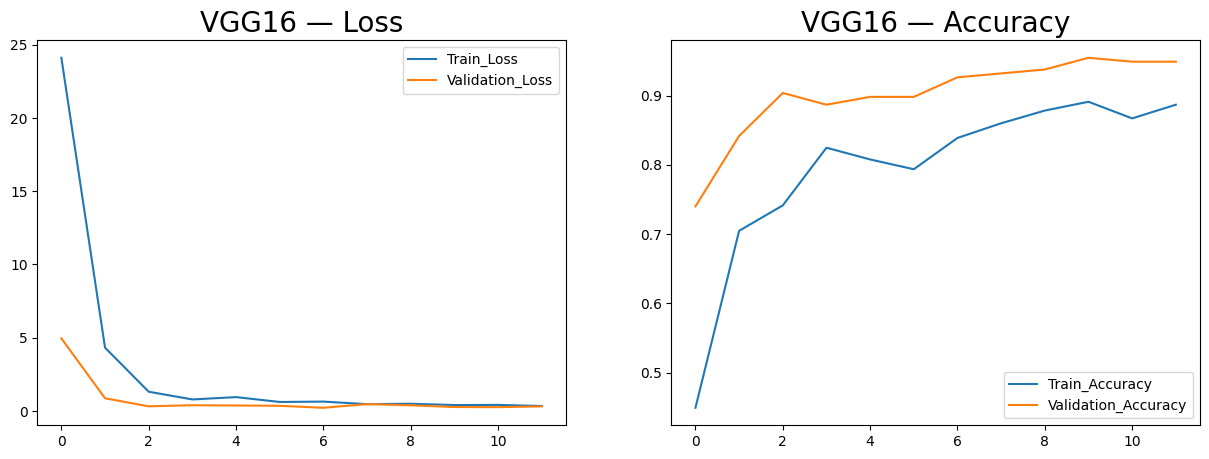

In [33]:
vgg_hist_ = pd.DataFrame(vgg_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_hist_['loss'], label='Train_Loss')
plt.plot(vgg_hist_['val_loss'], label='Validation_Loss')
plt.title('VGG16 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_hist_['accuracy'], label='Train_Accuracy')
plt.plot(vgg_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('VGG16 — Accuracy', fontsize=20)
plt.legend()
plt.show()

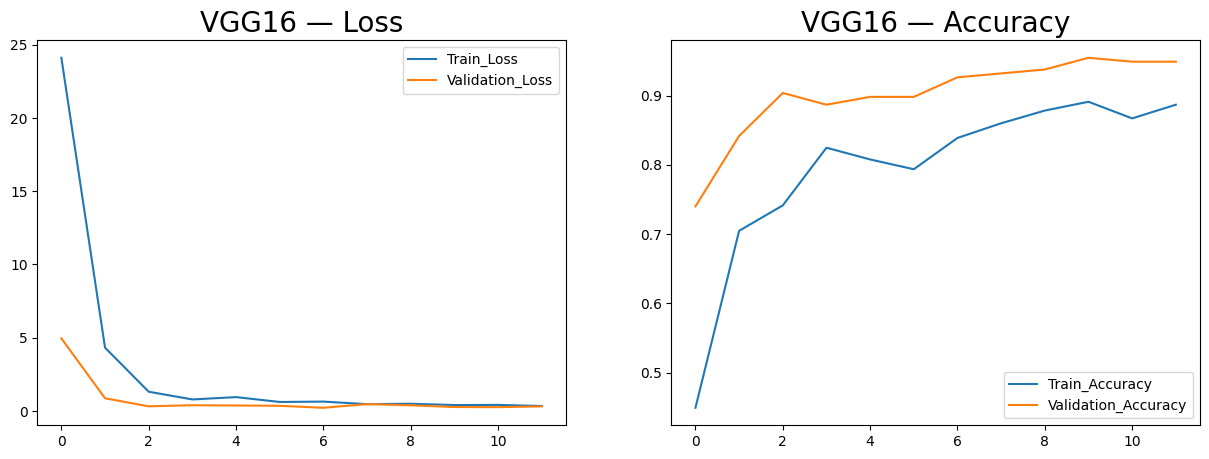

In [34]:
vgg_hist_ = pd.DataFrame(vgg_hist.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_hist_['loss'], label='Train_Loss')
plt.plot(vgg_hist_['val_loss'], label='Validation_Loss')
plt.title('VGG16 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_hist_['accuracy'], label='Train_Accuracy')
plt.plot(vgg_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('VGG16 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [36]:
vgg_y_pred = []
predictions_vgg = vgg_model.predict(np.array(X_val))
for i in predictions_vgg:
    vgg_y_pred.append(np.argmax(i))

print("VGG16 Accuracy:", accuracy_score(y_val, vgg_y_pred))
print(classification_report(y_val, vgg_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 127s 19s/step
VGG16 Accuracy: 0.9265536723163842
                   precision    recall  f1-score   support

        Bird-drop       0.98      0.92      0.95        48
            Clean       0.90      0.95      0.93        40
            Dusty       0.86      0.83      0.84        29
Electrical-damage       0.90      0.95      0.93        20
  Physical-Damage       0.92      0.92      0.92        13
     Snow-Covered       0.96      1.00      0.98        27

         accuracy                           0.93       177
        macro avg       0.92      0.93      0.92       177
     weighted avg       0.93      0.93      0.93       177



Model                Val Accuracy
MobileNetV2                0.9435
EfficientNetB0             0.9266
ShuffleNetV2               0.1638
VGG16                      0.9266


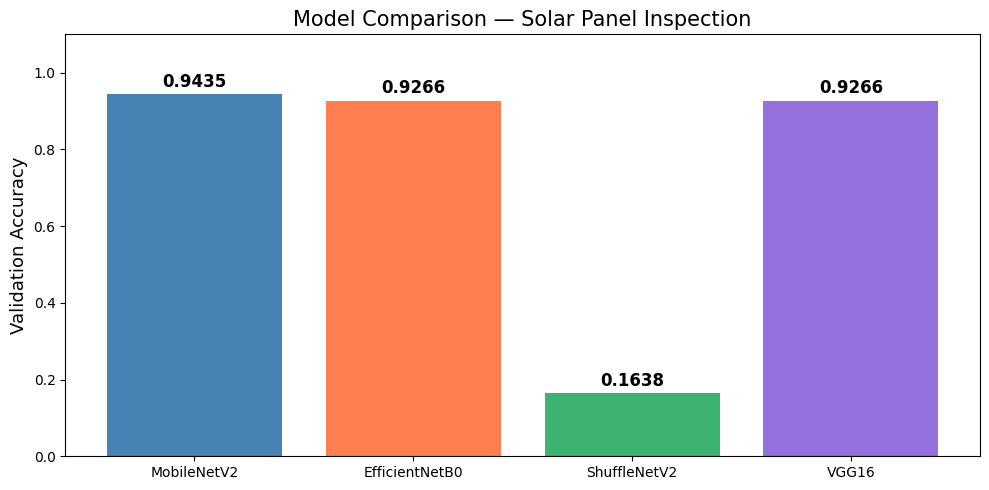

In [37]:
results = {
    'MobileNetV2':    accuracy_score(y_val, y_pred),
    'EfficientNetB0': accuracy_score(y_val, eff_y_pred),
    'ShuffleNetV2':   accuracy_score(y_val, shuffle_y_pred),
    'VGG16':          accuracy_score(y_val, vgg_y_pred),
}

print("=" * 42)
print(f"{'Model':<20} {'Val Accuracy':>12}")
print("=" * 42)
for model_name, acc in results.items():
    print(f"{model_name:<20} {acc:>12.4f}")
print("=" * 42)

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0, 1.1)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('Model Comparison — Solar Panel Inspection', fontsize=15)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f"{acc:.4f}", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

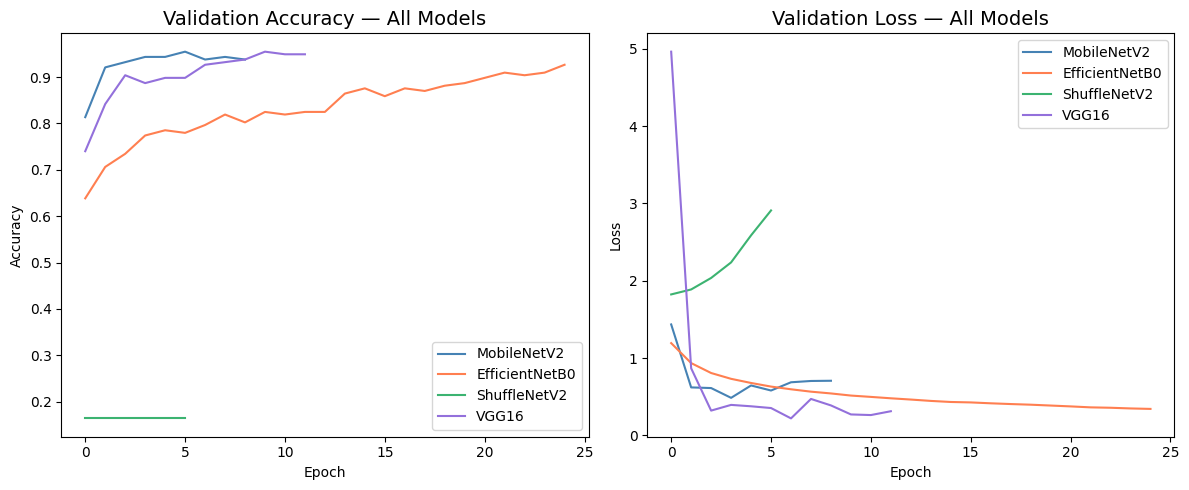

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_['val_accuracy'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_accuracy'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_accuracy'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_accuracy'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Accuracy — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_['val_loss'],         label='MobileNetV2',    color='steelblue')
plt.plot(eff_hist_['val_loss'],     label='EfficientNetB0', color='coral')
plt.plot(shuffle_hist_['val_loss'], label='ShuffleNetV2',   color='mediumseagreen')
plt.plot(vgg_hist_['val_loss'],     label='VGG16',          color='mediumpurple')
plt.title('Validation Loss — All Models', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
summary_data = {
    'Model':         ['MobileNetV2', 'EfficientNetB0', 'ShuffleNetV2', 'VGG16'],
    'Val Accuracy':  [
        round(accuracy_score(y_val, y_pred), 4),
        round(accuracy_score(y_val, eff_y_pred), 4),
        round(accuracy_score(y_val, shuffle_y_pred), 4),
        round(accuracy_score(y_val, vgg_y_pred), 4),
    ],
    'Trainable Params': [
        keras_model.count_params(),
        eff_model.count_params(),
        shuffle_model.count_params(),
        vgg_model.count_params(),
    ],
    'Type': ['Lightweight', 'Lightweight', 'Lightweight', 'Heavyweight']
}

summary_df = pd.DataFrame(summary_data).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
summary_df

,Model,Val Accuracy,Trainable Params,Type
0,MobileNetV2,0.9435,2634310,Lightweight
1,EfficientNetB0,0.9266,4057257,Lightweight
2,VGG16,0.9266,21139014,Heavyweight
3,ShuffleNetV2,0.1638,1055650,Lightweight
